# Finding third-order gates in codes

In [1]:
#%load_ext autoreload
#%autoreload 1
#%aimport homomorphism_kernels
import third_order_gates.z248_linalg as lin
#import scipy.linalg
import numpy as np
import third_order_gates.third_order_gates as tg


import sys
from pathlib import Path
project_root = Path.cwd().parents[0]
utilsdir = project_root / "utils"
if str(utilsdir) not in sys.path:
    sys.path.insert(0, str(utilsdir))

import utils

In [21]:
print(utils)

<module 'utils' (namespace) from ['/home/andi/Andi/research/fault_tolerance/third_order_gates/code/transversal-gate-finder/utils']>


## Steane code
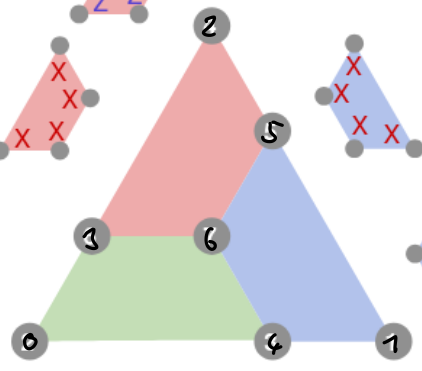

In [2]:
steane_code = tg.transversal_gate_finder(7, checks=[[0,3,4,6], [1,4,5,6], [2,3,5,6]], logicals=[[0,2,3]])
steane_code.add_t_gates_all()
steane_code.find_gates()
print("Transversal logicals")
steane_code.print_transversal_logicals()
print("Transversal stabilizers")
steane_code.print_physical_stabilizers()

Transversal logicals
T^6[0] * 

Transversal stabilizers
Physical stabilizers:
T^4[1] * T^4[2] * T^4[3] * T^4[4] * 
T^4[0] * T^4[1] * T^4[3] * T^4[5] * 
T^4[1] * T^4[4] * T^4[5] * T^4[6] * 



In [4]:
print(steane_code.find_phys_rep([1]).tostring())

| | 2 2 2 2 2 2 2 


## Stacked surface codes
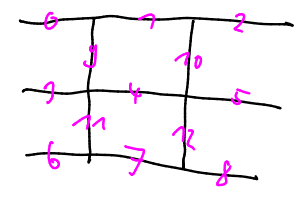

In [5]:
stacked_tc = tg.transversal_gate_finder(26)
stacked_tc.add_checks([[0, 9, 1], [1, 10, 2], [3, 9, 4, 11], [4, 10, 5, 12], [6, 11, 7], [7, 12, 8]])
unshifted_checks = [[0,3,9], [3,11,6], [1,4,9,10], [4,7,11,12], [2,10,5], [5,8,12]]
stacked_tc.add_checks([[x+13 for x in check] for check in unshifted_checks])
stacked_tc.add_logicals([[0,3,6]])
stacked_tc.add_logicals([[x+13 for x in logical] for logical in [[0,1,2]]])
stacked_tc.add_cs_gates([[i,i+13] for i in range(13)])
stacked_tc.add_t_gates_all()
stacked_tc.find_gates()
stacked_tc.print_transversal_logicals()

CS^2[0, 1] * 
T^4[0] * 
T^4[1] * 



In [6]:
print(stacked_tc.find_phys_rep([1,0,0]).tostring())

| 2 2 2 2 2 2 2 2 2 2 2 2 2 | 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 


## [15,1,3] 3D color code (or quantum Reed-Muller code)
<img src="attachment:4da704cf-e8a1-4cad-90f2-e4e237e3377f.png" width="300">

In [7]:
reed_muller = tg.transversal_gate_finder(15)
reed_muller.add_checks([[0,14,4,13,6,12,9,10], [1,14,4,13,5,11,8,10], [2,14,5,11,7,12,6,13], [3,14,9,10,8,11,7,12]])
reed_muller.add_logicals([[0,1,2,4,5,6,13]])
reed_muller.add_t_gates_all()
reed_muller.find_gates()
reed_muller.print_transversal_logicals()
#gate_locs = [all_single_locs(15), no_double_locs(), no_triple_locs()]
#find_logicals(15, gate_locs, check_list, logical_list)

T^7[0] * 



In [9]:
reed_muller.find_phys_rep([1]).tostring()

'| | 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 '

# 3D Toric code

In [2]:
# 3D toric code
tc_3d = tg.ti_transversal_gate_finder(3, 3)
tc_3d.add_checks([[([0,0,0], 0), ([0,0,0], 1), ([0,0,0], 2), ([-1,0,0], 0), ([0,-1,0], 1), ([0,0,-1], 2)]])
tc_3d.add_other_checks([[([0,0,0], 0), ([0,0,0], 1), ([0,1,0], 0), ([1,0,0], 1)], [([0,0,0], 0), ([0,0,0], 2), ([0,0,1], 0), ([1,0,0], 2)], [([0,0,0], 1), ([0,0,0], 2), ([0,0,1], 1), ([0,1,0], 2)]])
tc_3d_finite = tc_3d.as_finite_code(np.array([[2,0,1],[0,2,0],[0,0,2]]))
print("checks", tc_3d_finite.checks)
tc_3d_finite.logicals_from_other_checks()
print(tc_3d_finite.logicals)

checks [[0, 8, 16, 5, 10, 20], [1, 9, 17, 0, 11, 21], [2, 10, 18, 7, 8, 22], [3, 11, 19, 2, 9, 23], [4, 12, 20, 1, 14, 16], [5, 13, 21, 4, 15, 17], [6, 14, 22, 3, 12, 18], [7, 15, 23, 6, 13, 19]]
[[0, 2, 4, 6], [8, 9, 12, 13], [1, 3, 16, 17, 18, 19]]


# Transversal CCZ in 3 copies of 3D TC

In [4]:

tc_3d_x3 = tc_3d + tc_3d + tc_3d
# tc_3d_x3.add_checks(tc_3d.checks)
# tc_3d_x3.add_checks(tg.shift_loc_list(tc_3d.checks, 3))
# tc_3d_x3.add_checks(tg.shift_loc_list(tc_3d.checks, 6))
# tc_3d_x3.add_other_checks(tc_3d.other_checks)
# tc_3d_x3.add_other_checks(tg.shift_loc_list(tc_3d.other_checks, 3))
# tc_3d_x3.add_other_checks(tg.shift_loc_list(tc_3d.other_checks, 6))
tc_3d_x3.add_ccz_gates([[([0,0,0],0), ([1,0,0],4), ([1,1,0],8)],
                        [([0,0,0],0), ([1,0,0],5), ([1,0,1],7)],
                        [([0,0,0],1), ([0,1,0],3), ([1,1,0],8)],
                        [([0,0,0],1), ([0,1,0],5), ([0,1,1],6)],
                        [([0,0,0],2), ([0,0,1],3), ([1,0,1],7)],
                        [([0,0,0],2), ([0,0,1],4), ([0,1,1],6)]])

tc_3d_x3_finite = tc_3d_x3.as_finite_code(np.array([[3,0,0],[0,3,0],[0,0,3]]))
tc_3d_x3_finite.logicals_from_other_checks()
tc_3d_x3_finite.add_t_gates_all()
#print(tc_3d_x3_finite.ccz_gates)
#print("logicals", tc_3d_x3_finite.logicals)
tc_3d_x3_finite.find_gates()
tc_3d_x3_finite.print_transversal_logicals()

CCZ^1[0, 4, 8] * CCZ^1[0, 5, 7] * CCZ^1[1, 3, 8] * CCZ^1[1, 5, 6] * CCZ^1[2, 3, 7] * CCZ^1[2, 4, 6] * 
T^4[0] * 
T^4[1] * 
T^4[2] * 
T^4[3] * 
T^4[4] * 
T^4[5] * 
T^4[6] * 
T^4[7] * 
T^4[8] * 



In [11]:
print(tc_3d_x3_finite.find_phys_rep([1,1,0,1,0,0,0,1,1,0]).tostring())

1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 | | 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 4 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 


# BB codes

In [5]:
def twobga_code(dimension, poly1, poly2):
    code = tg.ti_transversal_gate_finder(2, dimension)
    code.add_checks([[(coord,0) for coord in poly1] + [(coord,1) for coord in poly2]])
    code.add_other_checks([[((-np.array(coord)).tolist(),1) for coord in poly1] + [((-np.array(coord)).tolist(),0) for coord in poly2]])
    return code

In [3]:
# define bb code as 2D code
# y+y^2+x^3, x+x^2+y^3 code (table 3 of original BB paper)
bb_code = twobga_code(2, [[1,0],[2,0],[0,3]], [[0,1],[0,2],[3,0]])
# this is the same as the y+y^2+x^3, x+x^2+y^3 code, just with the individual R and L qubits shifted and R and L swapped
# (taken from the drawing in the original BB paper)
#bb_code = twobga_code([[0,0],[0,1],[3,-1]], [[0,0],[1,0],[-1,3]])
pbc_lattice = np.array([[6,0],[0,6]])
bb_code_finite = bb_code.as_finite_code(pbc_lattice)
bb_code_finite.logicals_from_other_checks()
print(len(bb_code_finite.logicals), "logicals", bb_code_finite.logicals)

12 logicals [[3, 6, 12, 15, 18, 24], [4, 7, 13, 16, 19, 25], [5, 8, 14, 17, 20, 26], [0, 9, 12, 15, 21, 27], [3, 6, 9, 15, 21, 30], [4, 7, 10, 16, 22, 31], [0, 1, 3, 4, 6, 7, 9, 10, 36, 37, 39, 40], [0, 2, 3, 5, 6, 8, 9, 11, 36, 38, 39, 41], [0, 1, 2, 5, 6, 7, 8, 9, 12, 14, 37, 39, 42, 44], [2, 4, 6, 8, 13, 15, 36, 37, 38, 39, 43, 45], [2, 4, 7, 8, 9, 10, 12, 16, 36, 37, 38, 39, 42, 46], [0, 1, 4, 5, 6, 7, 8, 11, 13, 17, 36, 38, 43, 47]]


In [4]:
# Here we test the BB code as 4D code
bb_code_4d = twobga_code(4, [[0,0,0,0], [0,1,0,0],[0,0,0,1]],[[0,0,0,0],[1,0,0,0],[0,0,1,0]])
pbc_lattice = np.array([[6,0,0,0],[0,6,0,0],[3,-1,0,-1],[-1,3,-1,0]])
#pbc_lattice = np.array([[3,0,0,0],[0,3,0,0],[0,0,3,0],[0,0,0,3]])
print("l1 systole:", utils.l1_systole(pbc_lattice, 3)[0])
bb_code_4d_finite = bb_code_4d.as_finite_code(pbc_lattice)
bb_code_4d_finite.test_commutation()
bb_code_4d_finite.logicals_from_other_checks()
#print("checks", len(bb_code_finite.checks))
#for x in bb_code_4d_finite.checks:
#    print(x)
print(len(bb_code_4d_finite.logicals), "logicals", bb_code_4d_finite.logicals)
#print(~np.any(tg.transversal_gate_finder.matrix_from_list(72, bb_code_finite.checks) - tg.transversal_gate_finder.matrix_from_list(72, bb_code_4d_finite.checks)!=0))
#print(~np.any(tg.transversal_gate_finder.matrix_from_list(72, bb_code_finite.other_checks) - tg.transversal_gate_finder.matrix_from_list(72, bb_code_4d_finite.other_checks)!=0))

l1 systole: 4
X checks and Z checks commute: True
12 logicals [[3, 5, 12, 16, 19, 21], [0, 2, 7, 11, 20, 22], [4, 7, 9, 11, 20, 25], [0, 2, 4, 11, 18, 27], [2, 7, 9, 11, 18, 29], [3, 12, 14, 16, 23, 30], [0, 6, 7, 13, 15, 26, 36, 37, 38, 39, 40, 41], [3, 6, 7, 8, 17, 39, 40, 42], [8, 13, 14, 15, 16, 17, 37, 39, 43, 44], [0, 6, 13, 15, 16, 36, 37, 38, 43, 46], [5, 6, 7, 8, 14, 16, 17, 36, 39, 40, 43, 49], [0, 2, 6, 7, 8, 11, 13, 14, 16, 17, 36, 39, 43, 50]]


In [5]:
bb_code_4d_double = bb_code_4d + bb_code_4d.inverted_coordinates()
bb_code_4d_double.add_cs_gates([[([0,0,0,0],0), ([0,0,0,0],2)], [([0,0,0,0],0), ([0,0,0,0],3)], [([0,0,0,0],1), ([0,0,0,0],2)], [([0,0,0,0],1), ([0,0,0,0],3)]])
bb_code_4d_double_finite = bb_code_4d_double.as_finite_code(pbc_lattice)
bb_code_4d_double_finite.logicals_from_other_checks()
print(len(bb_code_4d_double_finite.logicals))
bb_code_4d_double_finite.find_gates()
bb_code_4d_double_finite.print_transversal_logicals()

24
CS^2[0, 19] * CS^2[0, 20] * CS^2[0, 22] * CS^2[0, 23] * CS^2[1, 20] * CS^2[1, 21] * CS^2[1, 22] * CS^2[2, 18] * CS^2[2, 21] * CS^2[2, 22] * CS^2[2, 23] * CS^2[3, 18] * CS^2[3, 20] * CS^2[3, 22] * CS^2[4, 18] * CS^2[4, 19] * CS^2[5, 18] * CS^2[5, 19] * CS^2[5, 20] * CS^2[5, 22] * CS^2[5, 23] * CS^2[6, 14] * CS^2[6, 15] * CS^2[6, 16] * CS^2[6, 17] * CS^2[6, 18] * CS^2[6, 19] * CS^2[6, 20] * CS^2[6, 21] * CS^2[7, 12] * CS^2[7, 13] * CS^2[7, 15] * CS^2[7, 16] * CS^2[7, 18] * CS^2[7, 19] * CS^2[7, 22] * CS^2[7, 23] * CS^2[8, 12] * CS^2[8, 14] * CS^2[8, 15] * CS^2[8, 18] * CS^2[8, 20] * CS^2[8, 22] * CS^2[8, 23] * CS^2[9, 13] * CS^2[9, 15] * CS^2[9, 18] * CS^2[9, 20] * CS^2[9, 21] * CS^2[10, 13] * CS^2[10, 14] * CS^2[10, 15] * CS^2[10, 18] * CS^2[10, 19] * CS^2[10, 20] * CS^2[10, 21] * CS^2[10, 22] * CS^2[11, 12] * CS^2[11, 13] * CS^2[11, 14] * CS^2[11, 16] * CS^2[11, 17] * CS^2[11, 19] * CS^2[11, 23] * 



In [6]:
print(bb_code_4d_double_finite.find_phys_rep([1]).tostring())

| 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 0 2 2 0 | 


# Haah cubic code

In [ ]:
haah_cubic = twobga_code(3, [[0,0,0],[0,0,1],[0,1,0],[1,0,0]], [[0,0,0],[0,1,1],[1,0,1],[1,1,0]])
haah_cubic.add_all_t()
haah_cubic.add_all_cs_onsite()
haah_cubic.add_all_cs_coord([1,0,0])
haah_cubic.add_all_cs_coord([0,1,0])
haah_cubic.add_all_cs_coord([0,0,1])
haah_cubic.add_all_ccz_onecoord([1,0,0])
haah_cubic.add_all_ccz_onecoord([0,1,0])
haah_cubic.add_all_ccz_onecoord([0,0,1])
print(haah_cubic.t_gates)
print(haah_cubic.cs_gates)
print(haah_cubic.ccz_gates)
haah_cubic_finite = haah_cubic.as_finite_code(np.array([[8,0,0],[0,8,0],[3,3,-1]]))
#haah_cubic_finite = haah_cubic.as_finite_code(np.array([[2,0,0],[0,2,0],[3,3,-1]]))
haah_cubic_finite.logicals_from_other_checks()
print(len(haah_cubic_finite.logicals))
haah_cubic_finite.find_gates()
haah_cubic_finite.print_transversal_logicals()


[[([0, 0, 0], 0)], [([0, 0, 0], 1)]]
[[([0, 0, 0], 0), ([0, 0, 0], 1)], [([0, 0, 0], 0), ([1, 0, 0], 0)], [([0, 0, 0], 0), ([1, 0, 0], 1)], [([0, 0, 0], 1), ([1, 0, 0], 0)], [([0, 0, 0], 1), ([1, 0, 0], 1)], [([0, 0, 0], 0), ([0, 1, 0], 0)], [([0, 0, 0], 0), ([0, 1, 0], 1)], [([0, 0, 0], 1), ([0, 1, 0], 0)], [([0, 0, 0], 1), ([0, 1, 0], 1)], [([0, 0, 0], 0), ([0, 0, 1], 0)], [([0, 0, 0], 0), ([0, 0, 1], 1)], [([0, 0, 0], 1), ([0, 0, 1], 0)], [([0, 0, 0], 1), ([0, 0, 1], 1)]]
[[([0, 0, 0], 0), ([1, 0, 0], 0), ([1, 0, 0], 1)], [([0, 0, 0], 1), ([1, 0, 0], 0), ([1, 0, 0], 1)], [([0, 0, 0], 0), ([0, 1, 0], 0), ([0, 1, 0], 1)], [([0, 0, 0], 1), ([0, 1, 0], 0), ([0, 1, 0], 1)], [([0, 0, 0], 0), ([0, 0, 1], 0), ([0, 0, 1], 1)], [([0, 0, 0], 1), ([0, 0, 1], 0), ([0, 0, 1], 1)]]
12


In [8]:
haah_cubic_finite.find_phys_rep([0,0,0,0,0,0,0,0,0,0,0,0,1]).tostring()

'0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2 0 0 2 0 0 0 0 0 0 0 0 2 2

# Old

## BB codes
BB codes are translation-invariant stabilizer codes with qubits on the edges of a $l\times m$ square lattice.
The checks involve 6 qubits, 3 horizontal and 3 vertical, at specific coordinates that are shifted.
The horizontal $Z$ check coordinates are inverses of the vertical $X$ check coordinates.

In [2]:
def bb_check_list(l, m, horizontal, vertical):
    def triple_to_qubit(xcoord, ycoord, orient):
        return l*m*orient + l*ycoord + xcoord
    check_triples = [[((x+sx) % l,(y+sy) % m,0) for (sx,sy) in horizontal] + [((x+sx) % l,(y+sy) % m,1) for (sx,sy) in vertical]  for x in range(l) for y in range(m)]
    check_list = [[triple_to_qubit(x, y, hv) for x,y,hv in check_triple] for check_triple in check_triples]
    return check_list

## [[98,8,10]] BB code
from [Eberhardt+Steffan 2024](https://arxiv.org/abs/2407.03973)
horizontal: (0,1), (3,0), (4,0)
vertical: (1,0), (0,3), (0,4)

In [ ]:
check_list_overcomplete = bb_check_list(7,7,[(0,1),(3,0),(4,0)], [(1,0),(0,3),(0,4)])

# define logicals
horizontal_logical_pairs = [(0,0),(1,0),(2,0),(5,0),(0,1),(1,1),(2,1),(5,1),(1,2),(3,2),(4,2),(5,2),(1,3),(2,3),(3,3),(6,3),(1,5),(2,5),(3,5),(6,5),(1,6),(3,6),(4,6),(5,6)] # coordinates for a single horizontal X logical
horizontal_logical_list = bb_check_list(7,7,horizontal_logical_pairs, [])
vertical_logical_pairs = [(y,x) for x,y in horizontal_logical_pairs]
vertical_logical_list = bb_check_list(7,7,[],vertical_logical_pairs)
logical_list_overcomplete = horizontal_logical_list + vertical_logical_list

# remove redundant checks and logicals
logicals_overcomplete = tg.transversal_gate_finder.matrix_from_list(98, logical_list_overcomplete)
checks_overcomplete = tg.transversal_gate_finder.matrix_from_list(98, check_list_overcomplete)
independent_check_nrs, independent_logical_nrs = hk.remove_image(checks_overcomplete, logicals_overcomplete)
logical_list = [logical_list_overcomplete[i] for i in independent_logical_nrs]
check_list = [check_list_overcomplete[i] for i in independent_check_nrs]
print(len(independent_check_nrs), "independent checks:\n", independent_check_nrs)
print(len(independent_logical_nrs), "independent logicals:\n", independent_logical_nrs)

# define gate locations: fold-transversal gate
double_gate_tuples = [[(x,y,0),((-1-y)%7,(-1-x)%7,0)] for x in range(7) for y in range(6-x)]
double_gate_tuples += [[(x,y,1),((-1-y)%7,(-1-x)%7,1)] for x in range(7) for y in range(6-x)]
double_gate_list = [[7*7*orient + 7*ycoord + xcoord for xcoord, ycoord, orient in double_gate_tuple] for double_gate_tuple in double_gate_tuples]
print(double_gate_list)
double_gate_locs = np.array(double_gate_list).T
#gate_locs = [all_single_locs(98), double_gate_locs, no_triple_locs()]

46 independent checks:
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]
6 independent logicals:
 [0, 1, 2, 49, 50, 51]
[[0, 48], [7, 47], [14, 46], [21, 45], [28, 44], [35, 43], [1, 41], [8, 40], [15, 39], [22, 38], [29, 37], [2, 34], [9, 33], [16, 32], [23, 31], [3, 27], [10, 26], [17, 25], [4, 20], [11, 19], [5, 13], [49, 97], [56, 96], [63, 95], [70, 94], [77, 93], [84, 92], [50, 90], [57, 89], [64, 88], [71, 87], [78, 86], [51, 83], [58, 82], [65, 81], [72, 80], [52, 76], [59, 75], [66, 74], [53, 69], [60, 68], [54, 62]]


In [ ]:
bb134 = tg.transversal_gate_finder(98)
bb134.set_checks_from_list(check_list)
bb134.set_logicals_from_list(logical_list)
bb134.set_ccz_locs_none()
bb134.set_t_locs_all()
bb134.gate_locs[1] = double_gate_locs

z_check_list = bb_check_list(7,7,[(-1,0),(0,-3),(0,-4)], [(0,-1),(-3,0),(-4,0)])
bb134.test_commutation(z_check_list)

X checks and Z checks commute: True
X logicals and Z checks commute: True


In [ ]:
# indeed finds fold-transversal Clifford gate from Eberhardt+Steffan 2024
bb134.find_gates()

Logical generators:
 T^4[1] * 
T^4[0] * T^4[1] * T^4[2] * 
T^4[2] * 
T^4[0] * T^4[3] * T^4[4] * 
T^4[0] * T^4[1] * T^4[5] * 
CS^2[0, 2] * CS^2[1, 2] * CS^2[3, 5] * CS^2[4, 5] * T^4[0] * T^2[1] * T^6[2] * T^4[3] * T^6[4] * T^2[5] * 

Physical representatives:
 T^4[3] * T^4[5] * T^4[7] * T^4[8] * T^4[9] * T^4[13] * T^4[16] * T^4[20] * T^4[23] * T^4[24] * T^4[26] * T^4[27] * T^4[28] * T^4[29] * T^4[31] * T^4[33] * T^4[35] * T^4[36] * T^4[37] * T^4[38] * T^4[40] * T^4[41] * T^4[42] * T^4[43] * 
T^4[3] * T^4[4] * T^4[5] * T^4[6] * T^4[10] * T^4[13] * T^4[14] * T^4[16] * T^4[17] * T^4[20] * T^4[21] * T^4[23] * T^4[25] * T^4[26] * T^4[28] * T^4[30] * T^4[31] * T^4[32] * T^4[33] * T^4[34] * T^4[39] * T^4[40] * T^4[42] * T^4[44] * 
T^4[0] * T^4[3] * T^4[4] * T^4[6] * T^4[8] * T^4[9] * T^4[11] * T^4[13] * T^4[14] * T^4[15] * T^4[16] * T^4[17] * T^4[18] * T^4[20] * T^4[22] * T^4[23] * T^4[32] * T^4[34] * T^4[35] * T^4[36] * T^4[37] * T^4[38] * T^4[42] * T^4[45] * 
T^4[0] * T^4[1] * T^4[3] * T^4[4

In [ ]:
# We only find Pauli logicals without folding for gate locations bounded by stabilizers
bb134.set_cs_locs_checks(check_list)
bb134.find_gates()

Logical generators:
 T^4[2] * 
T^4[0] * 
T^4[0] * T^4[1] * T^4[2] * 
T^4[0] * T^4[1] * T^4[3] * T^4[4] * 
T^4[0] * T^4[1] * T^4[2] * T^4[5] * 
T^4[4] * 

Physical representatives:
 CS^2[35, 88] * CS^2[47, 71] * CS^2[9, 72] * CS^2[42, 96] * CS^2[32, 78] * CS^2[5, 78] * CS^2[29, 54] * CS^2[27, 93] * CS^2[20, 90] * CS^2[35, 78] * CS^2[27, 97] * CS^2[42, 95] * CS^2[20, 67] * CS^2[32, 50] * CS^2[20, 94] * CS^2[5, 68] * CS^2[8, 88] * CS^2[15, 95] * CS^2[42, 67] * CS^2[0, 70] * CS^2[42, 85] * CS^2[20, 66] * CS^2[32, 49] * CS^2[8, 78] * CS^2[0, 92] * CS^2[12, 75] * CS^2[34, 81] * CS^2[15, 85] * CS^2[7, 81] * CS^2[42, 66] * CS^2[20, 56] * CS^2[22, 92] * CS^2[15, 89] * CS^2[34, 80] * CS^2[22, 96] * CS^2[7, 80] * CS^2[42, 56] * CS^2[47, 93] * CS^2[29, 72] * CS^2[0, 54] * CS^2[2, 72] * CS^2[34, 52] * CS^2[34, 70] * CS^2[22, 54] * CS^2[3, 50] * CS^2[32, 95] * CS^2[29, 53] * CS^2[34, 51] * CS^2[5, 72] * CS^2[25, 50] * CS^2[20, 93] * CS^2[22, 53] * CS^2[3, 49] * CS^2[9, 83] * CS^2[35, 67] * CS^2[47, 

In [ ]:
bb134.set_ccz_locs_checks(check_list)
print(bb134.gate_locs[2].shape)
bb134.find_gates()

(3, 920)
Logical generators:
 T^4[2] * 
T^4[0] * 
T^4[0] * T^4[1] * T^4[2] * 
T^4[0] * T^4[1] * T^4[3] * T^4[4] * 
T^4[0] * T^4[1] * T^4[2] * T^4[5] * 
T^4[4] * 

Physical representatives:
 CS^2[35, 88] * CS^2[47, 71] * CS^2[9, 72] * CS^2[42, 96] * CS^2[32, 78] * CS^2[5, 78] * CS^2[29, 54] * CS^2[27, 93] * CS^2[20, 90] * CS^2[35, 78] * CS^2[27, 97] * CS^2[42, 95] * CS^2[20, 67] * CS^2[32, 50] * CS^2[20, 94] * CS^2[5, 68] * CS^2[8, 88] * CS^2[15, 95] * CS^2[42, 67] * CS^2[0, 70] * CS^2[42, 85] * CS^2[20, 66] * CS^2[32, 49] * CS^2[8, 78] * CS^2[0, 92] * CS^2[12, 75] * CS^2[34, 81] * CS^2[15, 85] * CS^2[7, 81] * CS^2[42, 66] * CS^2[20, 56] * CS^2[22, 92] * CS^2[15, 89] * CS^2[34, 80] * CS^2[22, 96] * CS^2[7, 80] * CS^2[42, 56] * CS^2[47, 93] * CS^2[29, 72] * CS^2[0, 54] * CS^2[2, 72] * CS^2[34, 52] * CS^2[34, 70] * CS^2[22, 54] * CS^2[3, 50] * CS^2[32, 95] * CS^2[29, 53] * CS^2[34, 51] * CS^2[5, 72] * CS^2[25, 50] * CS^2[20, 93] * CS^2[22, 53] * CS^2[3, 49] * CS^2[9, 83] * CS^2[35, 67] * 

### BB codes as single 4D code
This doesn't quite work yet (doesn't coincide with 2D definition)

In [ ]:
bb_xcheck_list = [[([0,0,0,0], 0), ([0,0,0,0], 1), ([1,0,0,0], 0), ([0,1,0,0], 1), ([0,0,1,0], 0), ([0,0,0,1], 1)]]
bb_zcheck_list = [[([0,0,0,0], 0), ([0,0,0,0], 1), ([-1,0,0,0], 1), ([0,-1,0,0], 0), ([0,0,-1,0], 1), ([0,0,0,-1], 0)]]

bd_lattice = np.array([[6,0,0,0], [0,12,0,0], [3,-1,0,1], [-1,3,1,0]])
bb_xcheck = generate_ti_check_matrix(2, bb_xcheck_list, bd_lattice)
bb_zcheck = generate_ti_check_matrix(2, bb_zcheck_list, bd_lattice)

print("test x and z stabilizers commute:", ~np.any(bb_xcheck.T @ bb_zcheck % 2 == 1))
zker = hk.z2_kernel_bitgauss(bb_zcheck.T)
ind_xchecks, log_nrs = hk.remove_image(bb_xcheck, zker)
print("independent x checks\n", ind_xchecks)
logs = zker[:, log_nrs]
print(f"{logs.shape[1]} logical x operators\n", logs)

print("indep x checks\n", len(hk.injectify(bb_xcheck)))

test x and z stabilizers commute: True
independent x checks
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
0 logical x operators
 []
indep x checks
 72
